## using COlab GPU tp tune the model test if you are connected to GPU or not

In [ ]:
import os

gpu_env = os.environ.get("COLAB_GPU", "")

if gpu_env.isdigit() and int(gpu_env) > 0:
    print("**Connected to Google Colab GPU")
elif "COLAB_RELEASE_TAG" in os.environ:
    print("**Connected to Google Colab (CPU mode)")
else:
    print("*Running on Local Machine")


💻 Running on Local Machine


# Phase 3: Fine-Tuning YOLO & Class Optimization

## Objectives
1. Fine-tune YOLOv8 to improve vehicle detection recall.
2. Re-calibrate traffic-state thresholds to improve class F1-score.

This phase uses a newly created train/val/test split.

In [2]:
from pathlib import Path
import random, shutil
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from ultralytics import YOLO

## Step 1: Create New Train/Val/Test Split (Phase 3) and data_fineTune.yaml

Current dataset structure:
- train/images
- train/labels
- valid/images
- valid/labels

We combine train + valid,
then create a new 60/20/20 split.

In [3]:
from pathlib import Path
import random, shutil

# YOUR ACTUAL PATH
DATASET_ROOT = Path('../../data/Vehicle_Detection_Image_Dataset')

TRAIN_IMAGES = DATASET_ROOT / 'train' / 'images'
TRAIN_LABELS = DATASET_ROOT / 'train' / 'labels'
VALID_IMAGES = DATASET_ROOT / 'valid' / 'images'
VALID_LABELS = DATASET_ROOT / 'valid' / 'labels'

# New Phase 3 dataset folder
OUT_ROOT = Path('../../data/Vehicle_Detection_Image_Dataset_FineTune')

SEED = 42
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

# Collect all images from train + valid
all_images = list(TRAIN_IMAGES.glob('*')) + list(VALID_IMAGES.glob('*'))

random.seed(SEED)
random.shuffle(all_images)

n = len(all_images)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

train_imgs = all_images[:n_train]
val_imgs = all_images[n_train:n_train+n_val]
test_imgs = all_images[n_train+n_val:]

print(f"Total images: {n}")
print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")


def copy_pair(img_path, split):
    # Determine label location
    if "train" in str(img_path):
        label_path = TRAIN_LABELS / (img_path.stem + ".txt")
    else:
        label_path = VALID_LABELS / (img_path.stem + ".txt")

    dst_img_dir = OUT_ROOT / split / "images"
    dst_lab_dir = OUT_ROOT / split / "labels"

    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lab_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy2(img_path, dst_img_dir / img_path.name)
    shutil.copy2(label_path, dst_lab_dir / label_path.name)


for split_name, imgs in [("train", train_imgs),
                         ("val", val_imgs),
                         ("test", test_imgs)]:
    for img in imgs:
        copy_pair(img, split_name)

print("Fine tune split created successfully.")

Total images: 626
Train: 375, Val: 125, Test: 126
Fine tune split created successfully.


In [4]:
from pathlib import Path

DATASET_ROOT = Path('../../data/Vehicle_Detection_Image_Dataset')
TRAIN_IMAGES = DATASET_ROOT / 'train' / 'images'
VALID_IMAGES = DATASET_ROOT / 'valid' / 'images'

print("Notebook CWD:", Path().resolve())
print("DATASET_ROOT:", DATASET_ROOT.resolve(), "exists=", DATASET_ROOT.exists())
print("TRAIN_IMAGES:", TRAIN_IMAGES.resolve(), "exists=", TRAIN_IMAGES.exists())
print("VALID_IMAGES:", VALID_IMAGES.resolve(), "exists=", VALID_IMAGES.exists())

Notebook CWD: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\src\traffic-flow-reporter-poc
DATASET_ROOT: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\data\Vehicle_Detection_Image_Dataset exists= True
TRAIN_IMAGES: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\data\Vehicle_Detection_Image_Dataset\train\images exists= True
VALID_IMAGES: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\data\Vehicle_Detection_Image_Dataset\valid\images exists= True


In [5]:
yaml_path = OUT_ROOT / "data_fineTune.yaml"

# update these if your dataset has different classes/order
NAMES = ["car", "bus", "truck"]

yaml_text = f"""\
path: {OUT_ROOT}
train: train/images
val: val/images
test: test/images

names: {NAMES}
"""

yaml_path.write_text(yaml_text, encoding="utf-8")
print("Wrote:", yaml_path)
print(yaml_text)

Wrote: ..\..\data\Vehicle_Detection_Image_Dataset_FineTune\data_fineTune.yaml
path: ..\..\data\Vehicle_Detection_Image_Dataset_FineTune
train: train/images
val: val/images
test: test/images

names: ['car', 'bus', 'truck']



## Step 2: Fine-tune YOLOv8 (local)

Start with YOLOv8n for speed.
Use imgsz=640 for CPU, 960 for GPU.

If you're on CPU, do a smoke test first (epochs=1-5).

In [6]:
model = YOLO("yolov8n.pt")

train_results = model.train(
    data=str(yaml_path),
    epochs=20,      # CPU-friendly starter
    imgsz=640,      # keep 640 on CPU
    batch=16,        # lower if memory issues
    name="finetune_local",
    lr0=0.002,       # LR for fine-tuning
    device="cpu"    # change to "0" if you have NVIDIA GPU
)

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.18  Python-3.11.0 torch-2.10.0+cpu CPU (AMD Ryzen AI 7 350 w/ Radeon 860M)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\..\data\Vehicle_Detection_Image_Dataset_FineTune\data_fineTune.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937,

# Next Steps (after `model.train()`)

fine-tuned YOLOv8 and training automatically evaluated on the **val** split.  
Next, must (1) evaluate on the **held-out test split** and (2) re-run the **traffic-state boundary tuning** (Free/Moderate/Heavy) using the fine-tuned detector.

---

## Step 1: Load best fine-tuned weights
```python
from ultralytics import YOLO
from pathlib import Path

RUN_NAME = "finetune_local"   # change if your run name differs
best_pt = Path(f"runs/detect/{RUN_NAME}/weights/best.pt")

tuned = YOLO(str(best_pt))
print("Loaded:", best_pt)

In [7]:
from ultralytics import YOLO
from pathlib import Path

RUN_NAME = "finetune_local"   # change if your folder name is different

best_pt = Path(f"runs/detect/{RUN_NAME}/weights/best.pt")

print("Loading model from:", best_pt)

tuned = YOLO(str(best_pt))

Loading model from: runs\detect\finetune_local\weights\best.pt


In [ ]:
test_metrics = tuned.val(
    data=str(yaml_path),
    split="test",   # IMPORTANT: this is test
    imgsz=640,      # use same imgsz you trained with (or 960 if you trained at 960)
    device="cpu"    # change to "0" if you have GPU locally
)
test_metrics

Ultralytics 8.4.18  Python-3.11.0 torch-2.10.0+cpu CPU (AMD Ryzen AI 7 350 w/ Radeon 860M)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 270.150.0 MB/s, size: 58.0 KB)
val: Scanning C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\data\Vehicle_Detection_Image_Dataset_FineTune\test\labels.cache... 126 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 126/126  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4s/it 10.9s.5ss
                   all        126       1169      0.898      0.901      0.964      0.701
                   car        126       1169      0.898      0.901      0.964      0.701
Speed: 0.8ms preprocess, 68.1ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\src\traffic-flow-reporter-poc\runs\detect

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000174A0DA74D0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [9]:
from pathlib import Path

# 1) Print key detection metrics (Ultralytics stores them on the results object)
print("Detection metrics on TEST:")
print("mAP50-95:", float(test_metrics.box.map))      # overall mAP@[.50:.95]
print("mAP50   :", float(test_metrics.box.map50))    # mAP@0.50
print("mAP75   :", float(test_metrics.box.map75))    # mAP@0.75

# Some versions also have per-class arrays
try:
    print("mAP per class:", test_metrics.box.maps)   # list/array
except Exception as e:
    print("Per-class mAP not available in this version:", e)

# 2) Locate the run directory where Ultralytics saved images (confusion matrix, PR curve, etc.)
run_dir = Path(getattr(test_metrics, "save_dir", ""))
print("Saved evaluation artifacts in:", run_dir)

# Show common saved files if present
if run_dir and run_dir.exists():
    for f in ["confusion_matrix.png", "pr_curve.png", "results.png", "F1_curve.png", "P_curve.png", "R_curve.png"]:
        p = run_dir / f
        if p.exists():
            print("Found:", p)

Detection metrics on TEST:
mAP50-95: 0.700935171337479
mAP50   : 0.9637072906088113
mAP75   : 0.8679361476219065
mAP per class: [    0.70094     0.70094     0.70094]
Saved evaluation artifacts in: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\src\traffic-flow-reporter-poc\runs\detect\val5
Found: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\src\traffic-flow-reporter-poc\runs\detect\val5\confusion_matrix.png


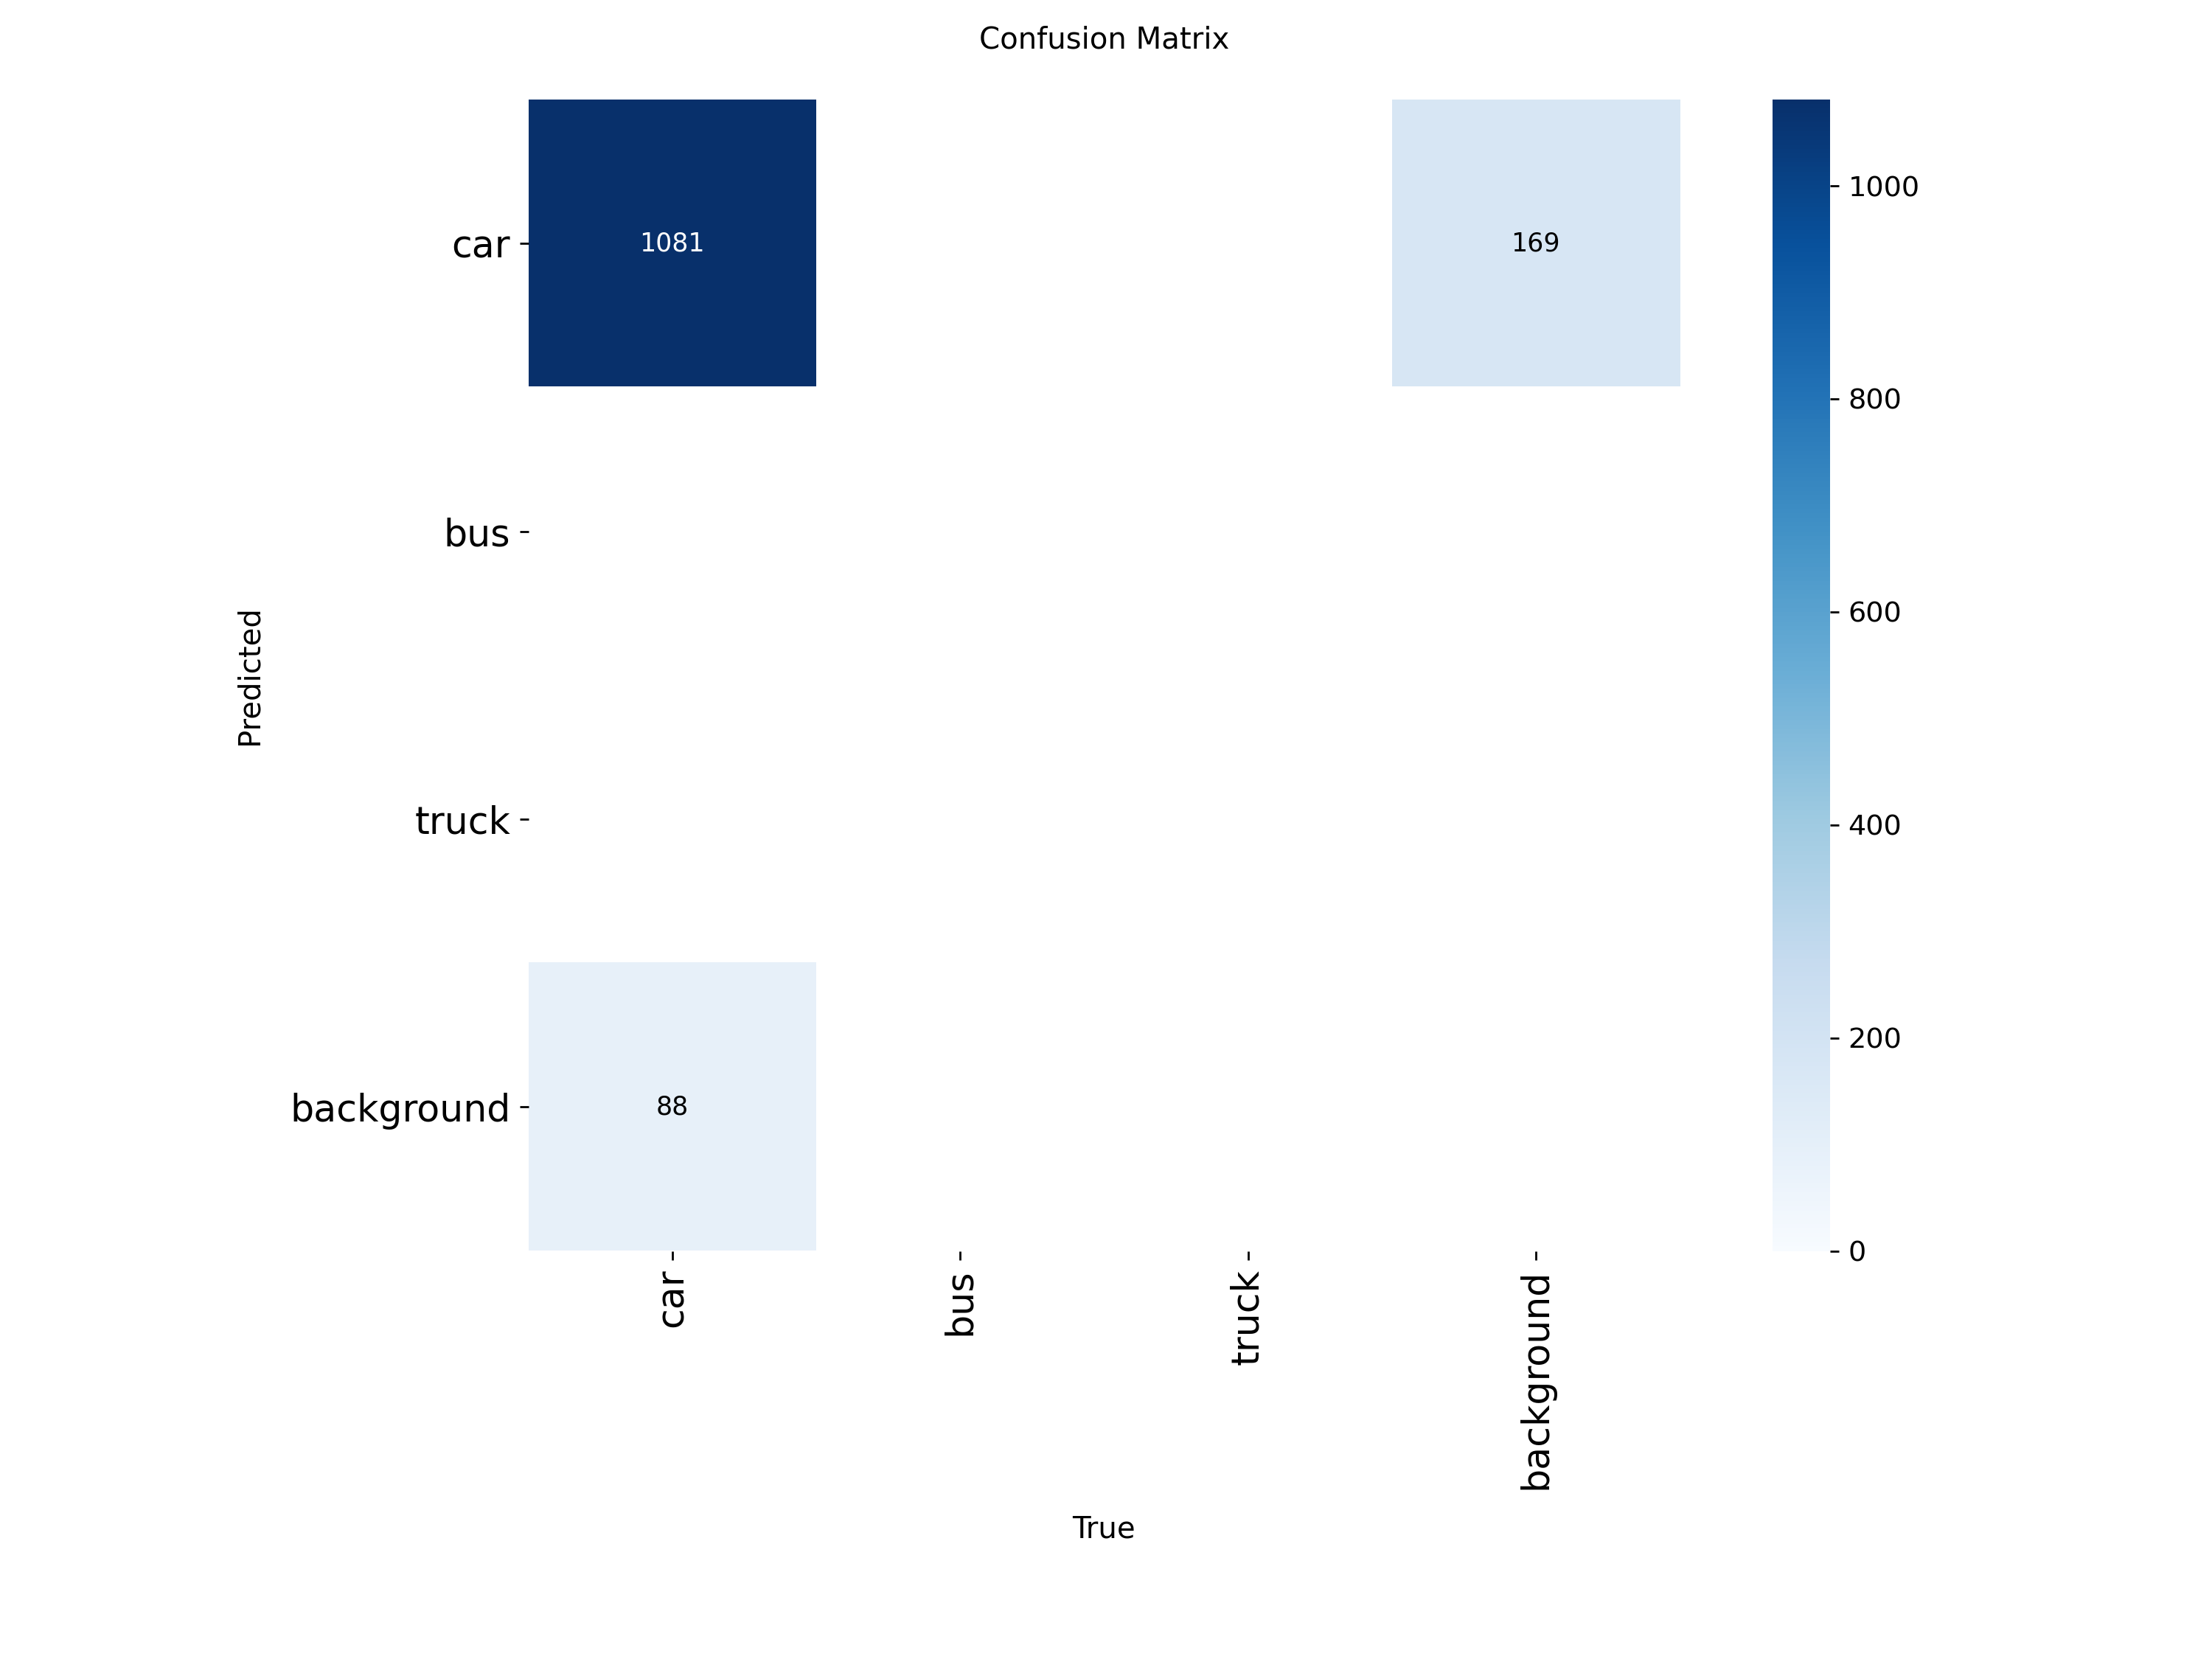

In [10]:
from IPython.display import Image, display
from pathlib import Path

cm_path = Path(test_metrics.save_dir) / "confusion_matrix.png"
if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print("confusion_matrix.png not found at:", cm_path)

In [11]:
from pathlib import Path

DATASET_ROOT = Path('../../data/Vehicle_Detection_Image_Dataset')

PHASE2_TRAIN_IMAGES_DIR = DATASET_ROOT / "train" / "images"
PHASE2_VALID_IMAGES_DIR = DATASET_ROOT / "valid" / "images"

print("CWD:", Path().resolve())
print("DATASET_ROOT:", DATASET_ROOT.resolve(), "exists=", DATASET_ROOT.exists())
print("train/images exists:", PHASE2_TRAIN_IMAGES_DIR.exists())
print("valid/images exists:", PHASE2_VALID_IMAGES_DIR.exists())

CWD: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\src\traffic-flow-reporter-poc
DATASET_ROOT: C:\Drexel_2242026\CS 614-686_Applications of M\Final Project\TrafficVision\data\Vehicle_Detection_Image_Dataset exists= True
train/images exists: True
valid/images exists: True


In [12]:
def resolve_img_path(fname: str) -> str:
    fname = Path(str(fname)).name  # keep only filename if CSV has paths
    p1 = PHASE2_TRAIN_IMAGES_DIR / fname
    if p1.exists():
        return str(p1)

    p2 = PHASE2_VALID_IMAGES_DIR / fname
    if p2.exists():
        return str(p2)

    raise FileNotFoundError(f"Could not find {fname} in train/images or valid/images")

In [ ]:
import pandas as pd

csv_path = "C:\\Drexel_2242026\\CS 614-686_Applications of M\\Final Project\\TrafficVision\\src\\traffic-flow-reporter-poc\\outputs\\labeled_counts.csv"  # <-- put correct filename here for your output file
df = pd.read_csv(csv_path)

print("Loaded rows:", len(df))
#df.head()


Loaded rows: 90


In [14]:

def count_vehicles_from_fname(fname: str) -> int:
    img_path = resolve_img_path(fname)
    r = tuned.predict(img_path, conf=0.25, iou=0.45, imgsz=640, verbose=False)[0]
    return 0 if r.boxes is None else len(r.boxes)

import pandas as pd

df["vehicle_count"] = df["image"].apply(count_vehicles_from_fname)
#df[["image", "true_label", "vehicle_count"]].head(1)


'''def count_vehicles(img_path: str) -> int:
    r = tuned.predict(img_path, conf=0.25, iou=0.45, imgsz=640, verbose=False)[0]
    return 0 if r.boxes is None else len(r.boxes)

df["vehicle_count"] = df["image"].apply(count_vehicles)
#df[["image", "true_label", "vehicle_count"]].head()'''

'def count_vehicles(img_path: str) -> int:\n    r = tuned.predict(img_path, conf=0.25, iou=0.45, imgsz=640, verbose=False)[0]\n    return 0 if r.boxes is None else len(r.boxes)\n\ndf["vehicle_count"] = df["image"].apply(count_vehicles)\n#df[["image", "true_label", "vehicle_count"]].head()'

In [15]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_true = df["true_label"].astype(str)

best_f1 = -1
best_pair = None
best_preds = None

for free_max in range(1, 41):
    for moderate_max in range(free_max + 2, 121):
        def classify(c):
            if c <= free_max: return "Free"
            if c <= moderate_max: return "Moderate"
            return "Heavy"

        preds = df["vehicle_count"].apply(classify)
        score = f1_score(y_true, preds, average="macro")
        if score > best_f1:
            best_f1 = score
            best_pair = (free_max, moderate_max)
            best_preds = preds

print("Best macro-F1:", best_f1)
print("Best thresholds: Free<=", best_pair[0], "Moderate<=", best_pair[1])
print("\n" + classification_report(y_true, best_preds, digits=4))
print("Confusion matrix (Free/Moderate/Heavy):")
print(confusion_matrix(y_true, best_preds, labels=["Free","Moderate","Heavy"]))

Best macro-F1: 0.7015924136697084
Best thresholds: Free<= 8 Moderate<= 14

              precision    recall  f1-score   support

        Free     0.7609    1.0000    0.8642        35
       Heavy     0.8529    0.8286    0.8406        35
    Moderate     0.6000    0.3000    0.4000        20

    accuracy                         0.7778        90
   macro avg     0.7379    0.7095    0.7016        90
weighted avg     0.7609    0.7778    0.7519        90

Confusion matrix (Free/Moderate/Heavy):
[[35  0  0]
 [ 9  6  5]
 [ 2  4 29]]


## side by side comparison of befroe fine tune and after fine tune evaluation matrices

In [16]:
import numpy as np

classes = ["Free", "Moderate", "Heavy"]

# BEFORE fine-tune (Phase 2)  
cm_before = np.array([
    [35, 0, 0],
    [ 10, 9, 1],
    [ 6, 10, 19]
])

# AFTER fine-tune (Phase 3) 
cm_after = np.array([
    [35, 0, 0],
    [ 9, 6, 5],
    [ 2, 4,29]
])

In [17]:
import pandas as pd

def metrics_from_cm(cm: np.ndarray, class_names):
    cm = np.array(cm)
    total = cm.sum()
    diag = np.diag(cm)

    row_sum = cm.sum(axis=1)  # true totals (support)
    col_sum = cm.sum(axis=0)  # predicted totals

    precision = np.divide(diag, col_sum, out=np.zeros_like(diag, dtype=float), where=col_sum!=0)
    recall    = np.divide(diag, row_sum, out=np.zeros_like(diag, dtype=float), where=row_sum!=0)
    f1        = np.divide(2*precision*recall, precision+recall, out=np.zeros_like(diag, dtype=float), where=(precision+recall)!=0)

    accuracy = diag.sum() / total if total else 0.0
    macro_f1 = float(f1.mean()) if len(f1) else 0.0
    moderate_f1 = float(f1[class_names.index("Moderate")]) if "Moderate" in class_names else float("nan")

    per_class = pd.DataFrame({
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": row_sum
    }, index=class_names)

    summary = {"accuracy": accuracy, "macro_f1": macro_f1, "moderate_f1": moderate_f1}
    return per_class, summary

In [18]:
per_before, sum_before = metrics_from_cm(cm_before, classes)
per_after,  sum_after  = metrics_from_cm(cm_after, classes)

print("=== BEFORE fine-tune (Phase 2) per-class ===")
display(per_before)
print("Summary:", sum_before)

print("\n=== AFTER fine-tune (Phase 3) per-class ===")
display(per_after)
print("Summary:", sum_after)

=== BEFORE fine-tune (Phase 2) per-class ===


,precision,recall,f1,support
Free,0.686275,1.000000,0.813953,35
Moderate,0.473684,0.450000,0.461538,20
Heavy,0.950000,0.542857,0.690909,35


Summary: {'accuracy': np.float64(0.7), 'macro_f1': 0.6554670136065485, 'moderate_f1': 0.46153846153846156}

=== AFTER fine-tune (Phase 3) per-class ===


,precision,recall,f1,support
Free,0.760870,1.000000,0.864198,35
Moderate,0.600000,0.300000,0.400000,20
Heavy,0.852941,0.828571,0.840580,35


Summary: {'accuracy': np.float64(0.7777777777777778), 'macro_f1': 0.7015924136697085, 'moderate_f1': 0.4}


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm, title in [
    (axes[0], cm_before, "BEFORE fine-tune (Phase 2)"),
    (axes[1], cm_after,  "AFTER fine-tune (Phase 3)")
]:
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

fig.savefig("before_after_confusion_matrices.png", dpi=200, bbox_inches="tight")
print("Saved: before_after_confusion_matrices.png")

<Figure size 1000x400 with 2 Axes>

Saved: before_after_confusion_matrices.png


In [20]:
metrics_df = pd.DataFrame(
    {
        "accuracy":    [sum_before["accuracy"],    sum_after["accuracy"]],
        "macro_f1":    [sum_before["macro_f1"],    sum_after["macro_f1"]],
        "moderate_f1": [sum_before["moderate_f1"], sum_after["moderate_f1"]],
    },
    index=["Before (Phase 2)", "After (Phase 3)"]
)

ax = metrics_df.plot(kind="bar", figsize=(8,4))
ax.set_ylim(0, 1.0)
ax.set_title("Before vs After Fine-tune: Accuracy / Macro F1 / Moderate F1")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("before_after_metrics.png", dpi=200, bbox_inches="tight")
print("Saved: before_after_metrics.png")

<Figure size 800x400 with 1 Axes>

Saved: before_after_metrics.png
